# EDA Notebook

We will use this notebook to evaluate and process our data from the CSV files.

In [6]:
print("Hello, Vibetastrophe Consulting!")

Hello, Vibetastrophe Consulting!


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Import CSV files into pandas

We will import the csv from the `data/raw/smart_city_csvs` folder.

In [9]:
#load the data
city_df = pd.read_csv('../data/raw/smart_city_csvs/city_traffic_accidents.csv')

urban_df = pd.read_csv('../data/raw/smart_city_csvs/urbanpulse_311_complaints.csv')

In [10]:
city_df.head(10)

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1784167,Source2,2,2019-10-29 13:16:54,2019-10-29 15:21:34,35.834797,-78.638512,NaN,NaN,0.000,...,False,False,False,False,False,False,Day,Day,Day,Day
1,A-862811,Source2,2,2021-10-13 06:30:00,2021-10-13 06:59:15,36.088970,-96.011734,NaN,NaN,0.000,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-4054572,Source1,2,2022-08-14 14:42:58,2022-08-14 16:27:58,33.537049,-86.794445,33.535373,-86.796156,0.152,...,False,False,False,False,False,False,Day,Day,Day,Day
3,A-6147589,Source1,2,2021-06-25 19:13:44,2021-06-25 20:42:30,34.071722,-117.612886,34.078917,-117.625339,0.869,...,False,False,False,False,False,False,Day,Day,Day,Day
4,A-5025169,Source1,2,2022-03-18 12:50:30,2022-03-18 13:13:00,40.324235,-76.790464,40.322625,-76.788114,0.166,...,False,False,False,False,False,False,Day,Day,Day,Day
5,A-4007360,Source1,2,2022-11-16 05:22:30.000000,2022-11-16 08:04:30.000000,34.024005,-117.557851,34.029942,-117.579011,1.279,...,False,False,False,False,False,False,Night,Night,Night,Day
6,A-2185422,Source2,2,2019-04-24 07:25:21,2019-04-24 08:25:01,34.136070,-80.880547,NaN,NaN,0.000,...,False,False,False,False,True,False,Day,Day,Day,Day
7,A-94012,Source2,2,2016-08-31 11:14:13,2016-08-31 11:44:13,34.245651,-118.874870,NaN,NaN,0.000,...,False,False,False,False,False,False,Day,Day,Day,Day
8,A-6717568,Source1,2,2020-10-24 20:15:00,2020-10-24 22:19:12,38.671507,-120.566459,38.671875,-120.566081,0.033,...,False,False,False,False,False,False,Night,Night,Night,Night
9,A-2960129,Source2,2,2018-03-21 20:44:14,2018-03-21 21:14:06,30.413244,-97.690582,NaN,NaN,0.000,...,False,False,False,False,True,False,Night,Night,Night,Day


In [11]:
urban_df.head(10)

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,resolution_description,borough,open_data_channel_type,status
0,67874778,2026-02-06T14:57:28.000,2026-02-07T21:24:52.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,This complaint is a duplicate of a building-wi...,MANHATTAN,ONLINE,Closed
1,68207007,2026-03-04T10:40:04.000,2026-03-06T16:05:24.000,HPD,Department of Housing Preservation and Develop...,PLUMBING,WATER SUPPLY,HPD conducted an inspection of this complaint....,BRONX,ONLINE,Closed
2,68298021,2026-03-12T11:26:42.000,2026-03-12T12:34:47.000,NYPD,New York City Police Department,Illegal Parking,Posted Parking Sign Violation,The New York City Police Department responded ...,BROOKLYN,MOBILE,Closed
3,67870560,2026-02-06T23:51:20.000,2026-02-09T12:21:00.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,HPD responded to a complaint of no heat or hot...,MANHATTAN,ONLINE,Closed
4,67844971,2026-02-03T10:01:52.000,2026-02-03T10:55:36.000,NYPD,New York City Police Department,Illegal Parking,Blocked Crosswalk,The New York City Police Department responded ...,BROOKLYN,MOBILE,Closed
5,68173650,2026-03-01T13:18:50.000,2026-03-01T13:41:16.000,NYPD,New York City Police Department,Illegal Parking,Posted Parking Sign Violation,The New York City Police Department responded ...,BROOKLYN,ONLINE,Closed
6,67996182,2026-02-14T04:34:09.000,2026-02-14T07:30:31.000,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,The New York City Police Department responded ...,BROOKLYN,MOBILE,Closed
7,67989111,2026-02-13T13:14:39.000,2026-02-15T21:30:43.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,APARTMENT ONLY,This complaint is a duplicate of a building-wi...,QUEENS,ONLINE,Closed
8,68284021,2026-03-10T08:15:03.000,2026-03-11T14:26:55.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,HPD responded to a complaint of no heat or hot...,MANHATTAN,ONLINE,Closed
9,67918125,2026-02-09T11:41:22.000,NaN,DOHMH,Department of Health and Mental Hygiene,Non-Residential Heat,Inadequate or No Heat,The Department of Health and Mental Hygiene ha...,BRONX,ONLINE,In Progress


In [12]:
# Seeing how many missing values there are in each column
missing_values_city = city_df.isnull().sum()
missing_values_urban = urban_df.isnull().sum()
print("Missing values in city_df:")
print(missing_values_city)
print("\nMissing values in urban_df:")
print(missing_values_urban)


Missing values in city_df:
ID                            0
Source                        0
Severity                      0
Start_Time                    0
End_Time                      0
Start_Lat                     0
Start_Lng                     0
End_Lat                  219978
End_Lng                  219978
Distance(mi)                  0
Description                   0
Street                      654
City                         28
County                        0
State                         0
Zipcode                     118
Country                       0
Timezone                    476
Airport_Code               1514
Weather_Timestamp          7842
Temperature(F)            10700
Wind_Chill(F)            129188
Humidity(%)               11371
Pressure(in)               9170
Visibility(mi)            11482
Wind_Direction            11382
Wind_Speed(mph)           36902
Precipitation(in)        142366
Weather_Condition         11300
Amenity                       0
Bump         

In [13]:
# df.info()
city_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     500000 non-null  str    
 1   Source                 500000 non-null  str    
 2   Severity               500000 non-null  int64  
 3   Start_Time             500000 non-null  str    
 4   End_Time               500000 non-null  str    
 5   Start_Lat              500000 non-null  float64
 6   Start_Lng              500000 non-null  float64
 7   End_Lat                280022 non-null  float64
 8   End_Lng                280022 non-null  float64
 9   Distance(mi)           500000 non-null  float64
 10  Description            500000 non-null  str    
 11  Street                 499346 non-null  str    
 12  City                   499972 non-null  str    
 13  County                 500000 non-null  str    
 14  State                  500000 non-null  str    

In [14]:
urban_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 434722 entries, 0 to 434721
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   unique_key              434722 non-null  int64
 1   created_date            434722 non-null  str  
 2   closed_date             384642 non-null  str  
 3   agency                  434722 non-null  str  
 4   agency_name             434722 non-null  str  
 5   complaint_type          434722 non-null  str  
 6   descriptor              431047 non-null  str  
 7   resolution_description  434722 non-null  str  
 8   borough                 434722 non-null  str  
 9   open_data_channel_type  434722 non-null  str  
 10  status                  434722 non-null  str  
dtypes: int64(1), str(10)
memory usage: 36.5 MB


In [15]:
#df.describe()
city_df.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,500000.000000,500000.000000,500000.000000,280022.000000,280022.000000,500000.000000,489300.000000,370812.000000,488629.000000,490830.000000,488518.000000,463098.000000,357634.000000
mean,2.212386,36.205450,-94.706816,36.269349,-95.712652,0.558359,61.657263,58.223946,64.802873,29.536751,9.090389,7.689107,0.008308
std,0.487531,5.076753,17.383787,5.269770,18.096908,1.719821,19.013075,22.385876,22.857251,1.007469,2.703371,5.283195,0.104710
min,1.000000,24.555269,-124.497585,24.571240,-124.497421,0.000000,-89.000000,-89.000000,1.000000,0.120000,0.000000,0.000000,0.000000
25%,2.000000,33.400517,-117.217072,33.461970,-117.747945,0.000000,49.000000,43.000000,48.000000,29.370000,10.000000,4.600000,0.000000
50%,2.000000,35.831195,-87.792388,36.191048,-88.022662,0.029000,64.000000,62.000000,67.000000,29.860000,10.000000,7.000000,0.000000
75%,2.000000,40.081910,-80.351962,40.176147,-80.243654,0.462000,76.000000,75.000000,84.000000,30.030000,10.000000,10.400000,0.000000
max,4.000000,48.993996,-67.113167,48.995141,-67.109242,138.910004,136.400000,136.000000,100.000000,58.630000,100.000000,131.000000,10.020000


In [16]:
urban_df.describe()

,unique_key
count,4.347220e+05
mean,6.808396e+07
std,1.547138e+05
min,6.780378e+07
25%,6.794857e+07
50%,6.808820e+07
75%,6.821571e+07
max,6.835334e+07


In [17]:
# Checking for duplicates
duplicates_city = city_df.duplicated().sum()
duplicates_urban = urban_df.duplicated().sum()
print(f"Number of duplicate rows in city_df: {duplicates_city}")
print(f"Number of duplicate rows in urban_df: {duplicates_urban}")


Number of duplicate rows in city_df: 0
Number of duplicate rows in urban_df: 0


In [15]:
# checking the dtypes
print("Data types in city_df:")
print(city_df.dtypes)
print("\nData types in urban_df:")
print(urban_df.dtypes)


Data types in city_df:
ID                        object
Source                    object
Severity                   int64
Start_Time                object
End_Time                  object
Start_Lat                float64
Start_Lng                float64
End_Lat                  float64
End_Lng                  float64
Distance(mi)             float64
Description               object
Street                    object
City                      object
County                    object
State                     object
Zipcode                   object
Country                   object
Timezone                  object
Airport_Code              object
Weather_Timestamp         object
Temperature(F)           float64
Wind_Chill(F)            float64
Humidity(%)              float64
Pressure(in)             float64
Visibility(mi)           float64
Wind_Direction            object
Wind_Speed(mph)          float64
Precipitation(in)        float64
Weather_Condition         object
Amenity             

In [18]:
print("\nData types in urban_df:")
print(urban_df.dtypes)



Data types in urban_df:
unique_key                int64
created_date                str
closed_date                 str
agency                      str
agency_name                 str
complaint_type              str
descriptor                  str
resolution_description      str
borough                     str
open_data_channel_type      str
status                      str
dtype: object


In [21]:
# Running the df.describe on both CSVs to get a statistical summary of the data
print("Statistical summary of city_df:")
print(city_df.describe())



Statistical summary of city_df:
            Severity      Start_Lat      Start_Lng        End_Lat  \
count  500000.000000  500000.000000  500000.000000  280022.000000   
mean        2.212386      36.205450     -94.706816      36.269349   
std         0.487531       5.076753      17.383787       5.269770   
min         1.000000      24.555269    -124.497585      24.571240   
25%         2.000000      33.400517    -117.217072      33.461970   
50%         2.000000      35.831195     -87.792388      36.191048   
75%         2.000000      40.081910     -80.351962      40.176147   
max         4.000000      48.993996     -67.113167      48.995141   

             End_Lng   Distance(mi)  Temperature(F)  Wind_Chill(F)  \
count  280022.000000  500000.000000   489300.000000  370812.000000   
mean      -95.712652       0.558359       61.657263      58.223946   
std        18.096908       1.719821       19.013075      22.385876   
min      -124.497421       0.000000      -89.000000     -89.000000

In [22]:
print("\nStatistical summary of urban_df:")
print(urban_df.describe())


Statistical summary of urban_df:
         unique_key
count  4.347220e+05
mean   6.808396e+07
std    1.547138e+05
min    6.780378e+07
25%    6.794857e+07
50%    6.808820e+07
75%    6.821571e+07
max    6.835334e+07


In [23]:
# Running the df.shape on both CSVs to see the number of rows and columns in each dataset
print(f"Shape of city_df: {city_df.shape}")
print(f"Shape of urban_df: {urban_df.shape}")


Shape of city_df: (500000, 46)
Shape of urban_df: (434722, 11)


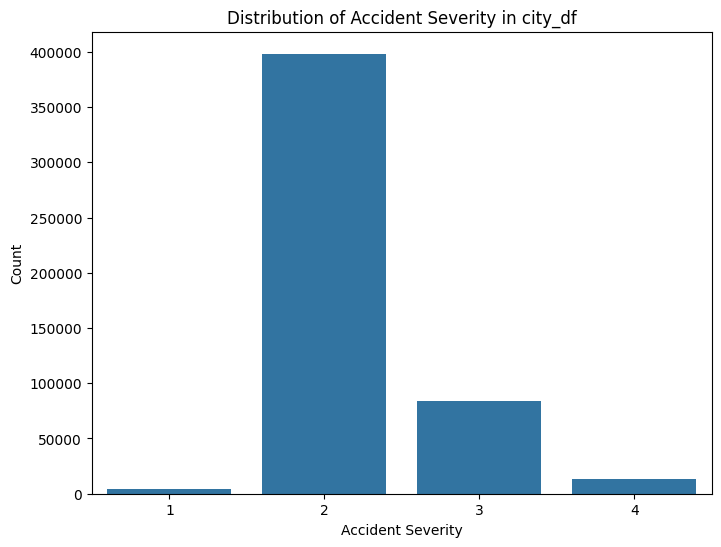

In [24]:
# plotting target variable distribution for city_df
plt.figure(figsize=(8, 6))
sns.countplot(x='Severity', data=city_df)
plt.title('Distribution of Accident Severity in city_df')
plt.xlabel('Accident Severity')
plt.ylabel('Count')
plt.show()


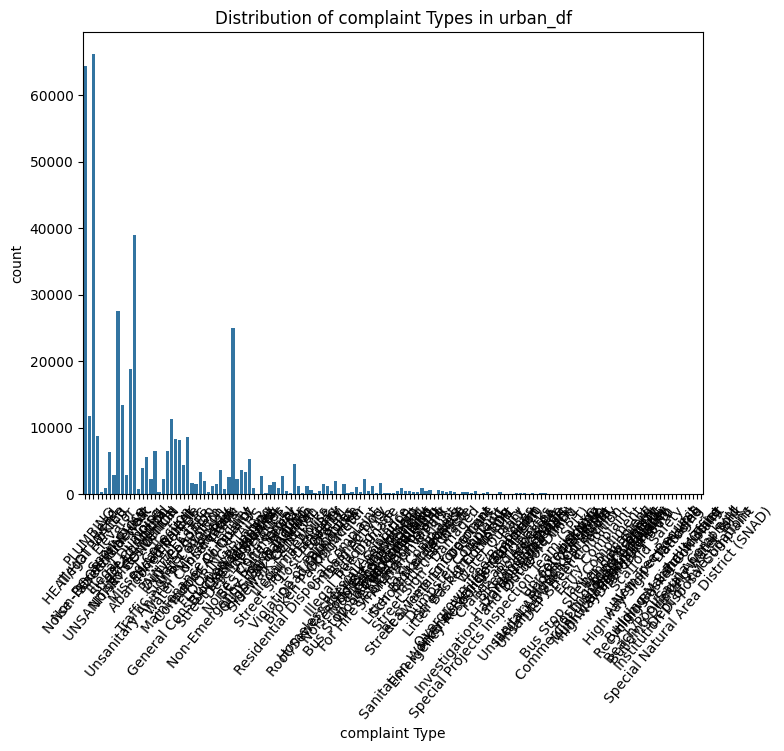

In [32]:
# plotting target variable distribution for urban_df
plt.figure(figsize=(8, 6))
sns.countplot(x='complaint_type', data=urban_df)
plt.title('Distribution of complaint Types in urban_df')
plt.xlabel('complaint Type')
plt.ylabel('count')
plt.xticks(rotation=50)
plt.show()

In [30]:
# Checking for Class Imbalance in the target variable 'Severity' in city_df
severity_counts = city_df['Severity'].value_counts()
print("Counts of each class in 'Severity':")
print(severity_counts)


Counts of each class in 'Severity':
Severity
2    398335
3     84063
4     13244
1      4358
Name: count, dtype: int64


In [33]:
# checking for class imbalance in the target variable 'complaint_type' in urban_df
complaint_counts = urban_df['complaint_type'].value_counts()
print("Counts of each class in 'complaint_type':")
print(complaint_counts)



Counts of each class in 'complaint_type':
complaint_type
Illegal Parking                   66159
HEAT/HOT WATER                    64362
Noise - Residential               38931
Snow or Ice                       27453
Blocked Driveway                  24920
                                  ...  
Illegal Animal Sold                   2
Found Property                        1
Building Marshal's Office             1
Institution Disposal Complaint        1
Dept of Investigations                1
Name: count, Length: 151, dtype: int64


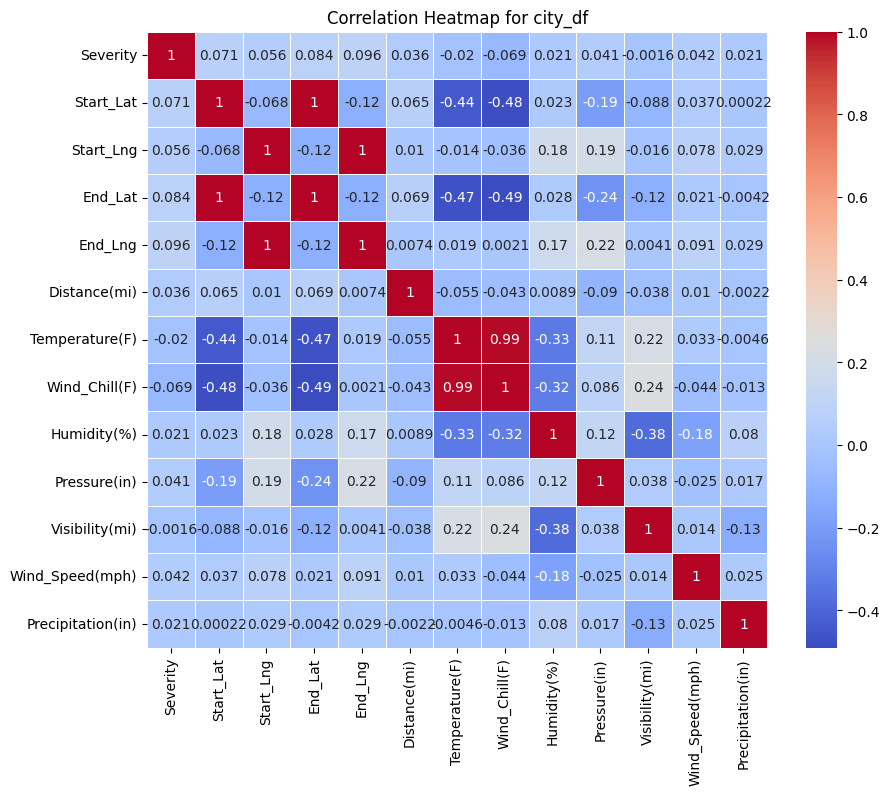

In [36]:
# Correlation heatmap for df_city — numeric columns only
numeric_city = city_df.select_dtypes(include='number')
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_city.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap for city_df')
plt.show()


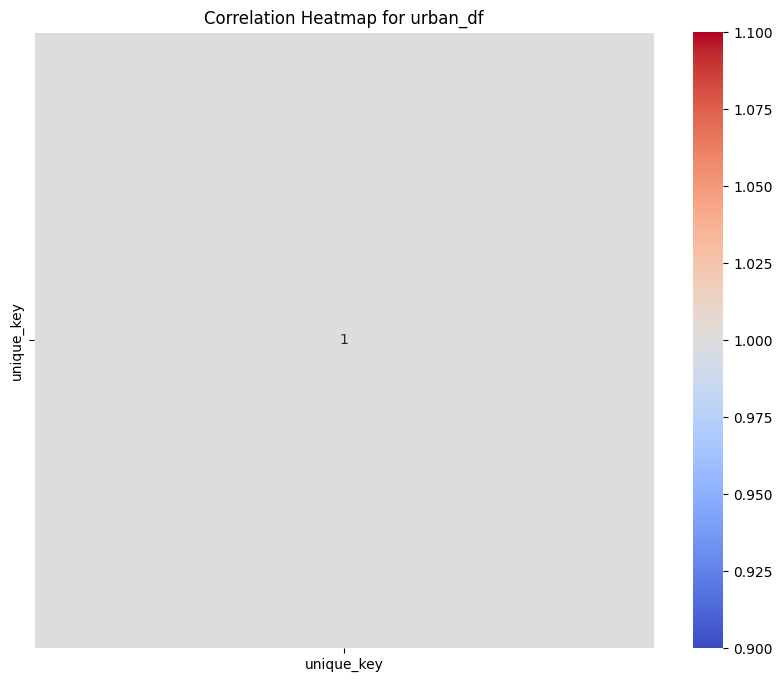

In [37]:
# Selecting only numeric columns from urban_df for correlation heatmap
numeric_urban = urban_df.select_dtypes(include='number')
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_urban.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap for urban_df')
plt.show()


In [38]:
# Selecting targets and features for both datasets
# For city_df, target variable is 'Severity' and features are all other columns
# For urban_df, target variable is 'complaint_type' and features are all other columns
target_city = 'Severity'
features_city = city_df.columns.drop(target_city)
target_urban = 'complaint_type'
features_urban = urban_df.columns.drop(target_urban)
print(f"Target variable for city_df: {target_city}")
print(f"Feature columns for city_df: {features_city}")
print(f"Target variable for urban_df: {target_urban}")
print(f"Feature columns for urban_df: {features_urban}")


Target variable for city_df: Severity
Feature columns for city_df: Index(['ID', 'Source', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng',
       'End_Lat', 'End_Lng', 'Distance(mi)', 'Description', 'Street', 'City',
       'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code',
       'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)',
       'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)',
       'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing',
       'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station',
       'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop',
       'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='str')
Target variable for urban_df: complaint_type
Feature columns for urban_df: Index(['unique_key', 'created_date', 'closed_date', 'agency', 'agency_name',
       'descriptor', 'resolution_description', 'boroug

In [ ]:
# See all columns and their types in both datasets
print("Columns and data types in city_df:")
print(city_df.dtypes)


Columns and data types in city_df:
ID                           str
Source                       str
Severity                   int64
Start_Time                   str
End_Time                     str
Start_Lat                float64
Start_Lng                float64
End_Lat                  float64
End_Lng                  float64
Distance(mi)             float64
Description                  str
Street                       str
City                         str
County                       str
State                        str
Zipcode                      str
Country                      str
Timezone                     str
Airport_Code                 str
Weather_Timestamp            str
Temperature(F)           float64
Wind_Chill(F)            float64
Humidity(%)              float64
Pressure(in)             float64
Visibility(mi)           float64
Wind_Direction               str
Wind_Speed(mph)          float64
Precipitation(in)        float64
Weather_Condition            str
Amenity 

In [40]:
# See all columns and thier types in both datasets
print("\nColumns and data types in urban_df:")
print(urban_df.dtypes)



Columns and data types in urban_df:
unique_key                int64
created_date                str
closed_date                 str
agency                      str
agency_name                 str
complaint_type              str
descriptor                  str
resolution_description      str
borough                     str
open_data_channel_type      str
status                      str
dtype: object


In [41]:
#  Preview just the text-like columns
text_cols = urban_df.select_dtypes(include='object').columns
print(text_cols.tolist())
urban_df[text_cols].head(5)

['created_date', 'closed_date', 'agency', 'agency_name', 'complaint_type', 'descriptor', 'resolution_description', 'borough', 'open_data_channel_type', 'status']


C:\Users\Groveman\AppData\Local\Temp\ipykernel_30240\2948066062.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = urban_df.select_dtypes(include='object').columns


,created_date,closed_date,agency,agency_name,complaint_type,descriptor,resolution_description,borough,open_data_channel_type,status
0,2026-02-06T14:57:28.000,2026-02-07T21:24:52.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,This complaint is a duplicate of a building-wi...,MANHATTAN,ONLINE,Closed
1,2026-03-04T10:40:04.000,2026-03-06T16:05:24.000,HPD,Department of Housing Preservation and Develop...,PLUMBING,WATER SUPPLY,HPD conducted an inspection of this complaint....,BRONX,ONLINE,Closed
2,2026-03-12T11:26:42.000,2026-03-12T12:34:47.000,NYPD,New York City Police Department,Illegal Parking,Posted Parking Sign Violation,The New York City Police Department responded ...,BROOKLYN,MOBILE,Closed
3,2026-02-06T23:51:20.000,2026-02-09T12:21:00.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,HPD responded to a complaint of no heat or hot...,MANHATTAN,ONLINE,Closed
4,2026-02-03T10:01:52.000,2026-02-03T10:55:36.000,NYPD,New York City Police Department,Illegal Parking,Blocked Crosswalk,The New York City Police Department responded ...,BROOKLYN,MOBILE,Closed


In [42]:
# Checking which columns have long text (not just codes/categories)
for col in urban_df.select_dtypes(include='object').columns:
    avg_len = urban_df[col].dropna().str.len().mean()
    print(f"{col:40s}  avg length: {avg_len:.0f} chars")

C:\Users\Groveman\AppData\Local\Temp\ipykernel_30240\223152257.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in urban_df.select_dtypes(include='object').columns:


created_date                              avg length: 23 chars
closed_date                               avg length: 23 chars
agency                                    avg length: 4 chars
agency_name                               avg length: 36 chars
complaint_type                            avg length: 15 chars
descriptor                                avg length: 16 chars
resolution_description                    avg length: 354 chars
borough                                   avg length: 7 chars
open_data_channel_type                    avg length: 6 chars
status                                    avg length: 6 chars


In [45]:
# Which columns are worth keeping as features?
# Drop obvious non-features first
drop_cols = ['ID', 'Source', 'Description', 'Street', 'City', 'County',
             'Zipcode', 'Country', 'Timezone', 'Airport_Code', 
             'Weather_Timestamp', 'End_Lat', 'End_Lng']

# Check how many unique values categorical columns have
for col in city_df.select_dtypes(include='object').columns:
    if col not in drop_cols:
        print(f"{col}: {city_df[col].nunique()} unique values")

C:\Users\Groveman\AppData\Local\Temp\ipykernel_30240\724903315.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in city_df.select_dtypes(include='object').columns:


Start_Time: 486961 unique values
End_Time: 493706 unique values
State: 49 unique values
Wind_Direction: 24 unique values
Weather_Condition: 106 unique values
Sunrise_Sunset: 2 unique values
Civil_Twilight: 2 unique values
Nautical_Twilight: 2 unique values
Astronomical_Twilight: 2 unique values


In [46]:
# Severity correlation with numeric features 
numeric_cols = city_df.select_dtypes(include='number').columns
city_df[numeric_cols].corr()['Severity'].sort_values(ascending=False)

Severity             1.000000
End_Lng              0.095693
End_Lat              0.084475
Start_Lat            0.070908
Start_Lng            0.055784
Wind_Speed(mph)      0.041659
Pressure(in)         0.041373
Distance(mi)         0.035802
Humidity(%)          0.020999
Precipitation(in)    0.020966
Visibility(mi)      -0.001561
Temperature(F)      -0.019604
Wind_Chill(F)       -0.068562
Name: Severity, dtype: float64

In [47]:
print("=== ACCIDENTS: Severity Distribution ===")
severity_counts = city_df['Severity'].value_counts().sort_index()
severity_pct = city_df['Severity'].value_counts(normalize=True).sort_index() * 100

for sev in severity_counts.index:
    print(f"  Severity {sev}: {severity_counts[sev]:>7,} records  ({severity_pct[sev]:.1f}%)")

=== ACCIDENTS: Severity Distribution ===
  Severity 1:   4,358 records  (0.9%)
  Severity 2: 398,335 records  (79.7%)
  Severity 3:  84,063 records  (16.8%)
  Severity 4:  13,244 records  (2.6%)


In [48]:
print("=== 311 COMPLAINTS: Complaint Category Distribution ===")

top_5 = ['Illegal Parking', 'HEAT/HOT WATER', 'Noise - Residential',
         'Snow or Ice', 'Blocked Driveway']

urban_df['complaint_category'] = urban_df['complaint_type'].apply(
    lambda x: x if x in top_5 else 'Other'
)

cat_counts = urban_df['complaint_category'].value_counts()
cat_pct = urban_df['complaint_category'].value_counts(normalize=True) * 100

for cat in cat_counts.index:
    print(f"  {cat:<30} {cat_counts[cat]:>7,} records  ({cat_pct[cat]:.1f}%)")

=== 311 COMPLAINTS: Complaint Category Distribution ===
  Other                          212,897 records  (49.0%)
  Illegal Parking                 66,159 records  (15.2%)
  HEAT/HOT WATER                  64,362 records  (14.8%)
  Noise - Residential             38,931 records  (9.0%)
  Snow or Ice                     27,453 records  (6.3%)
  Blocked Driveway                24,920 records  (5.7%)


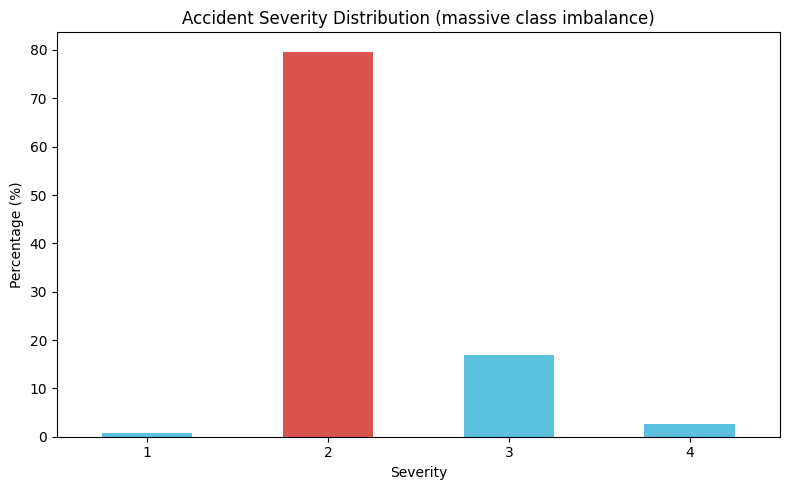

In [50]:
# Visualizin imbalance in the target variable 'Severity' in city_df
plt.figure(figsize=(8, 5))
severity_pct.plot(kind='bar', color=['#d9534f' if x == 2 else '#5bc0de' 
                                    for x in severity_pct.index])
plt.title('Accident Severity Distribution (massive class imbalance)')
plt.xlabel('Severity')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# EDA Summary — Vibetastrophe Consulting Smart City Capstone

## Dataset Overview
| Dataset | Rows | Columns |
|---------|------|---------|
| city_traffic_accidents.csv | 500,000 | 46 |
| urbanpulse_311_complaints.csv | 434,722 | 11 |

## Key Findings

### Accidents Dataset (Models 1 & 2)
- **Target column:** `Severity` (1–4 scale, measures traffic impact)
- **No duplicates found**
- **Major class imbalance:**
  - Severity 1: 4,358 records (0.9%) ← nearly invisible to models
  - Severity 2: 398,335 records (79.7%) ← dominant class
  - Severity 3: 84,063 records (16.8%)
  - Severity 4: 13,244 records (2.6%)
- **Key missing values to address:**
  - End_Lat / End_Lng: ~220,000 missing (44%) — drop these columns
  - Precipitation(in): 142,366 missing — drop or flag
  - Wind_Chill(F): 129,188 missing — drop or flag
  - Wind_Speed(mph): 36,902 missing — drop
  - Weather columns (Temp, Humidity, etc.): ~10,000 missing — drop
- **Features to drop:** ID, Source, Description, Street, City, County,
  Zipcode, Country, Timezone, Airport_Code, Weather_Timestamp
- **Strong features to keep:** All 13 boolean road features, temporal
  features (hour, day_of_week, month from Start_Time), weather features,
  Distance(mi), Sunrise_Sunset

### 311 Complaints Dataset (Model 4)
- **Target column:** `complaint_type` → mapped to `complaint_category` (6 classes)
- **Input text column:** `resolution_description`
- **No duplicates found**
- **Class imbalance (after mapping top 5 + Other):**
  - Other: 212,897 (49.0%) ← dominant catch-all
  - Illegal Parking: 66,159 (15.2%)
  - HEAT/HOT WATER: 64,362 (14.8%)
  - Noise - Residential: 38,931 (9.0%)
  - Snow or Ice: 27,453 (6.3%)
  - Blocked Driveway: 24,920 (5.7%)
- **Missing values:** Only descriptor (3,675) and closed_date (50,080) — 
  neither needed for Model 4

## Decisions Made
1. **Keep all 4 severity classes** for Models 1 & 2 (not collapsing to binary)
2. **Use `class_weight='balanced'`** in all sklearn models — mandatory
3. **Use weighted F1** as primary evaluation metric — NOT accuracy
4. **Use `resolution_description`** as NLP input text for Model 4
5. **Use top 5 complaint types + Other** (6 classes) for Model 4 target

## Next Steps
1. Build `pipelines/data_pipeline.py` with cleaning + feature engineering
2. Train Model 1 (XGBoost/RandomForest) on accidents data
3. Train Model 2 (Keras DNN) on same accidents data
4. Hand off 311 findings to NLP lead for Model 4

